# PLECS Simulation Runner
### Parameter Sweep & Monte Carlo — General Purpose Interface

**Workflow:** Configure → Connect → Run → Inspect signals → Plot → Save → Close

---
### How signals flow from PLECS to Python

Add an **Outport** block on the **top-level** schematic of your model  
(Component → Signal Sources → Outport). Wire all signals into it via a **Mux** block.


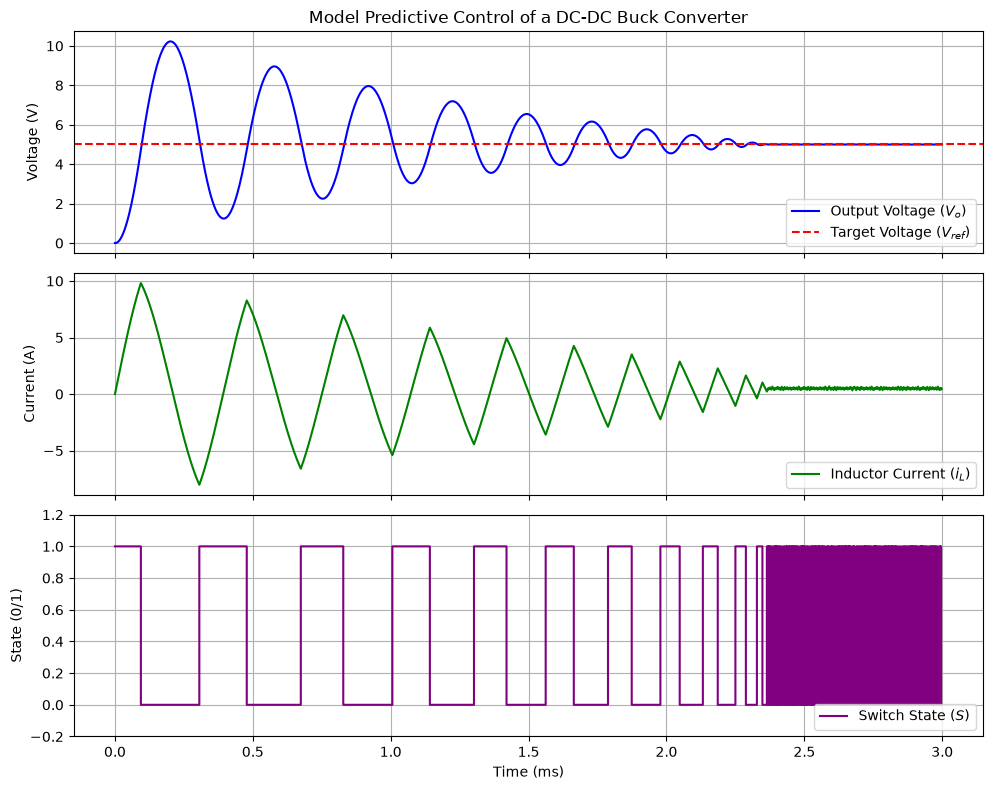

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. System Parameters & Configuration
# ---------------------------------------------------------
Vin = 12.0          # Input Voltage (V)
Vref = 5.0          # Target Output Voltage (V)
L = 100e-6          # Inductor (H)
C = 100e-6          # Capacitor (F)
R = 10.0            # Load Resistor (Ohm)
Ts = 2e-6           # Sampling Time (2 microseconds)
t_final = 0.003     # Simulation time (3 ms)

# Time vector
time_base = np.arange(0, t_final, Ts)
N = len(time_base)

# State initialization: [iL, vo]
iL = np.zeros(N)
vo_base = np.zeros(N)
S_history = np.zeros(N)

# ---------------------------------------------------------
# 2. Forward Prediction Function
# ---------------------------------------------------------
def predict_next_state(iL_k, vo_k, S_val):
    """Predicts next state given current state and candidate switch state."""
    diL_dt = (Vin * S_val - vo_k) / L
    dvo_dt = (iL_k - vo_k / R) / C
    
    iL_next = iL_k + Ts * diL_dt
    vo_next = vo_k + Ts * dvo_dt
    return iL_next, vo_next

# ---------------------------------------------------------
# 3. Main MPC Control Loop
# ---------------------------------------------------------

horizon = 2

for k in range(N - 1):
    best_cost = float('inf')
    best_S = 0
    
    # Evaluate candidates for current step S[k]
    for S_0 in [0, 1]:
        # Step 1 prediction
        iL_1, vo_1 = predict_next_state(iL[k], vo_base[k], S_0)
        
        # Step 2 prediction (assuming same state sequence or optimal sequence)
        for S_1 in [0, 1]:
            iL_2, vo_2 = predict_next_state(iL_1, vo_1, S_1)
            
            # Cost evaluated at horizon end
            cost = (vo_2 - Vref)**2
            
            if cost < best_cost:
                best_cost = cost
                best_S = S_0  # Store first action
                
    S_history[k] = best_S
    iL[k+1], vo_base[k+1] = predict_next_state(iL[k], vo_base[k], best_S)

S_history[-1] = S_history[-2]

# ---------------------------------------------------------
# 4. Graph Visualization
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Subplot 1: Output Voltage
axs[0].plot(time_base * 1e3, vo_base, label="Output Voltage ($V_o$)", color="blue", lw=1.5)
axs[0].axhline(y=Vref, color="r", linestyle="--", label="Target Voltage ($V_{ref}$)")
axs[0].set_ylabel("Voltage (V)")
axs[0].set_title("Model Predictive Control of a DC-DC Buck Converter")
axs[0].grid(True)
axs[0].legend(loc="lower right")

# Subplot 2: Inductor Current
axs[1].plot(time_base * 1e3, iL, label="Inductor Current ($i_L$)", color="green", lw=1.5)
axs[1].set_ylabel("Current (A)")
axs[1].grid(True)
axs[1].legend(loc="lower right")

# Subplot 3: Switching State
axs[2].step(time_base * 1e3, S_history, label="Switch State ($S$)", color="purple", where='post')
axs[2].set_ylabel("State (0/1)")
axs[2].set_xlabel("Time (ms)")
axs[2].set_ylim(-0.2, 1.2)
axs[2].grid(True)
axs[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

---
##  Configuration
**This is the only cell you normally need to edit.**

In [12]:
import itertools
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------
# 1. System Parameters
# ---------------------------------------------------------
Vin = 12.0          # Input Voltage (V)
Vref = 5.0          # Target Voltage (V)
L = 100e-6          # Inductor (H)
C = 100e-6          # Capacitor (F)
R = 10.0            # Load Resistor (Ohm)
Ts = 2e-6           # Sampling Time (s)
t_final = 0.003     # Simulation Time (3 ms)

# Prediction horizon setting (Change N_horizon to 2, 3, etc.)
N_horizon = 10       

time = np.arange(0, t_final, Ts)
N_sim = len(time)

iL = np.zeros(N_sim)
vo = np.zeros(N_sim)
S_history = np.zeros(N_sim)

# ---------------------------------------------------------
# 2. Physics & MPC Functions
# ---------------------------------------------------------
def predict_next_state(iL_k, vo_k, S_val):
    """Calculates state derivative and predicts state at k+1."""
    diL_dt = (Vin * S_val - vo_k) / L
    dvo_dt = (iL_k - vo_k / R) / C
    return iL_k + Ts * diL_dt, vo_k + Ts * dvo_dt

def evaluate_horizon(iL_start, vo_start, sequence):
    """Simulates system over candidate sequence and returns final voltage error."""
    curr_iL, curr_vo = iL_start, vo_start
    for S_val in sequence:
        curr_iL, curr_vo = predict_next_state(curr_iL, curr_vo, S_val)
    return (curr_vo - Vref) ** 2

# Generate all possible switching combinations (2^N_horizon)
switching_candidates = list(itertools.product([0, 1], repeat=N_horizon))

# ---------------------------------------------------------
# 3. Main MPC Simulation Loop
# ---------------------------------------------------------
for k in range(N_sim - 1):
    best_cost = float('inf')
    best_sequence = switching_candidates[0]
    
    # Evaluate every candidate path over the horizon
    for seq in switching_candidates:
        cost = evaluate_horizon(iL[k], vo[k], seq)
        if cost < best_cost:
            best_cost = cost
            best_sequence = seq
            
    # Apply FIRST action of optimal sequence
    best_S = best_sequence[0]
    S_history[k] = best_S
    iL[k+1], vo[k+1] = predict_next_state(iL[k], vo[k], best_S)

S_history[-1] = S_history[-2]

# ---------------------------------------------------------
# 4. Interactive Plotly Visualization
# ---------------------------------------------------------
fig = make_subplots(
    rows=3, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        f"Output Voltage (N_horizon = {N_horizon})", 
        "Inductor Current", 
        "Switch State S"
    )
)

# Output Voltage Trace
fig.add_trace(go.Scatter(x=time*1e3, y=vo, name="Vo horizon " + str(N_horizon) + " steps", line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=time*1e3, y=[Vref]*N_sim, name="Vref", line=dict(color='red', dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=time_base*1e3, y=vo_base, name="Vo horizon 2 steps", line=dict(color='brown')), row=1, col=1)

# Inductor Current Trace
fig.add_trace(go.Scatter(x=time*1e3, y=iL, name="iL", line=dict(color='green')), row=2, col=1)

# Switch State Trace
fig.add_trace(go.Scatter(x=time*1e3, y=S_history, name="State S", line=dict(color='purple', shape='hv')), row=3, col=1)

# Layout Setup
fig.update_xaxes(title_text="Time (ms)", row=3, col=1)
fig.update_yaxes(title_text="Voltage (V)", row=1, col=1)
fig.update_yaxes(title_text="Current (A)", row=2, col=1)
fig.update_yaxes(title_text="State (0/1)", row=3, col=1)

fig.update_layout(
    height=700, 
    width=900, 
    title_text=f"FCS-MPC Buck Converter Simulation (Horizon = {N_horizon} steps)",
    showlegend=True
)

fig.show()